# MNIST 손글씨 분류 — 단일 퍼셉트론(SLP)

PyTorch로 가장 단순한 신경망인 **단일 퍼셉트론(Single Layer Perceptron)** 을 만들어 MNIST 손글씨 숫자를 분류합니다. 이후 차시의 MLP/CNN과 비교하기 위한 출발점입니다.

## 학습 목표
- PyTorch의 기본 학습 파이프라인(데이터 로더 → 모델 → 손실 → 옵티마이저 → 학습 루프)을 이해한다.
- `nn.Linear` 한 층만으로 구성된 SLP의 구조와 한계를 파악한다.
- 학습/평가 함수를 분리해 작성하고 `model.train()` / `model.eval()` 모드를 구분해 사용한다.
- 테스트 정확도와 예측 결과를 시각화로 검증한다.

## 사용 라이브러리
- `torch`, `torch.nn`, `torch.optim` — 모델 정의 · 학습
- `torchvision` — MNIST 데이터셋 및 전처리
- `matplotlib`, `numpy` — 이미지/예측 시각화

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 하이퍼파라미터 및 디바이스 설정

학습률, 배치 크기, epoch 수 등 학습 전반을 제어하는 값을 한 셀에 모아 정의합니다. CUDA 사용 가능 여부를 확인해 자동으로 GPU/CPU를 선택합니다.

| 파라미터 | 값 | 의미 |
| --- | --- | --- |
| `batch_size` | 64 | 학습 미니배치 크기 |
| `epochs` | 10 | 전체 데이터셋 반복 횟수 |
| `lr` | 0.01 | RMSprop 학습률 |
| `log_interval` | 200 | 학습 로그 출력 주기 |

In [2]:
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 0.01
momentum = 0.01
gpu_use = True
log_interval = 200

cuda_use = gpu_use and torch.cuda.is_available()

print(cuda_use)

device = torch.device("cuda" if cuda_use else "cpu")

# kwargs = {'num_workers': 1, 'pin_memory': True} if cuda_use else {}

print("set hyperparameters done")

True
set hyperparameters done


## 데이터 로더 구성

`torchvision.datasets.MNIST`로 학습/테스트 데이터를 받아오고 `DataLoader`로 미니배치 단위 반복자를 만듭니다. `transforms.ToTensor()`는 PIL 이미지를 [0,1] 범위 텐서로 변환합니다.

In [3]:
transform = transforms.Compose([transforms.ToTensor()]) 

train_loader = torch.utils.data.DataLoader(
  datasets.MNIST('../data', train=True, download=True, 
                 transform=transform), 
    batch_size = batch_size, shuffle=True) #, **kwargs)

test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=False, download=True,
                 transform=transform), 
    batch_size=test_batch_size, shuffle=True) #, **kwargs)

print('data loading done')

data loading done


## 데이터 시각화

학습 데이터에서 36개 샘플을 그리드로 출력하고, 한 장은 픽셀 값까지 확대해 살펴봅니다. MNIST는 28×28 그레이스케일 이미지로, 각 픽셀이 0~1 사이의 값을 가집니다.

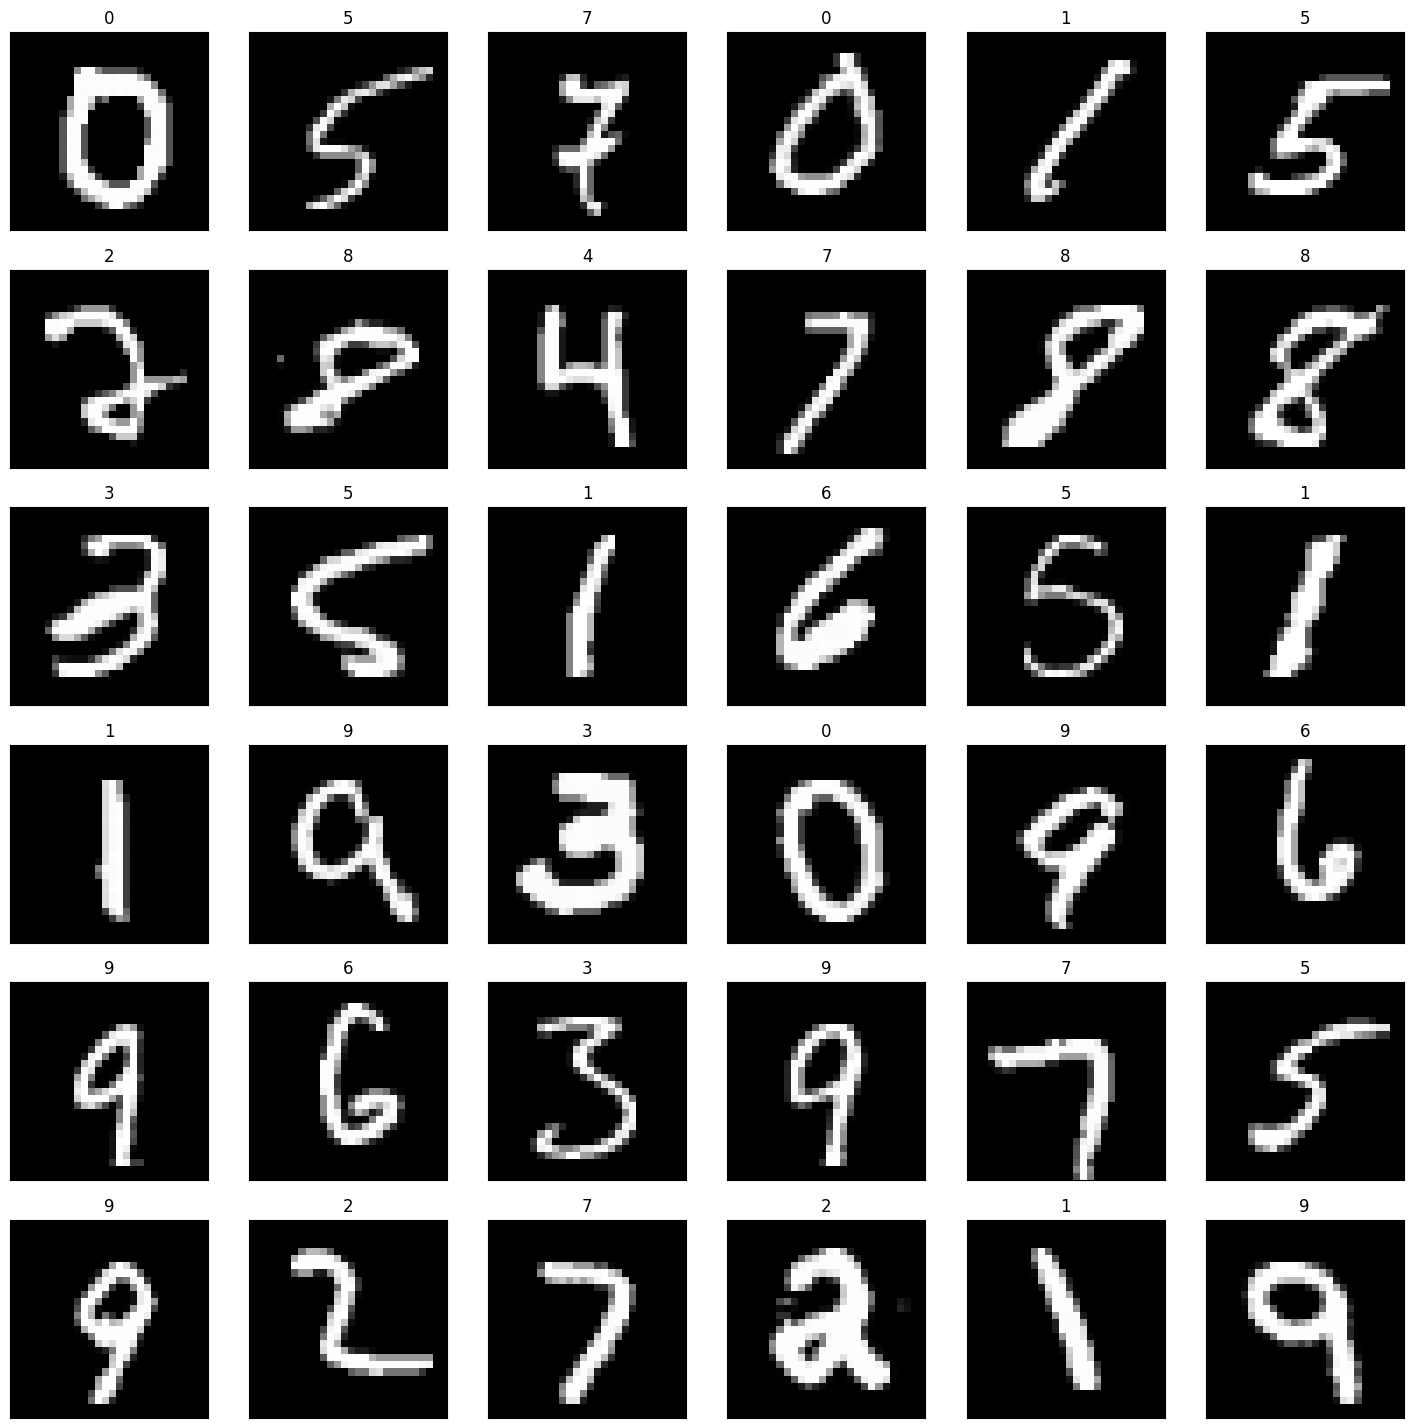

In [4]:
# obtain one batch of training images
import numpy as np
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot 18" x 18" 
fig = plt.figure(figsize=(18, 18))
for idx in range(36):
    number = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    number.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    number.set_title(str(labels[idx].item()))

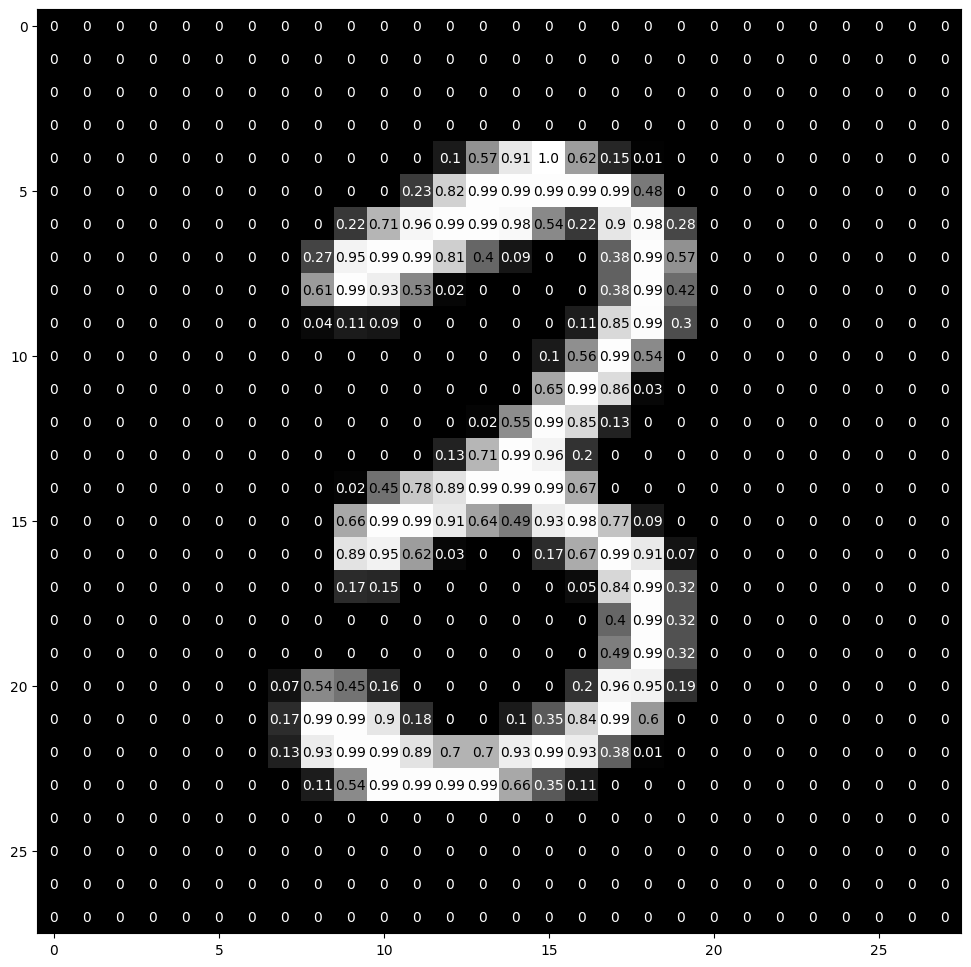

In [5]:
img = np.squeeze(images[43])

fig = plt.figure(figsize = (12,12)) 
big_number = fig.add_subplot(111)
big_number.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        big_number.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

## SLP 모델 정의

**단일 퍼셉트론(SLP)** 은 입력 784 차원을 곧바로 10개 클래스 점수로 매핑하는 가장 단순한 신경망입니다.

| 항목 | 값 |
| --- | --- |
| 입력 | 28×28 이미지를 펼친 784 차원 벡터 |
| 출력 | 10개 클래스(0~9) 로그-확률 |
| 파라미터 수 | 784 × 10 + 10 = 7,850 |
| 활성화 | ReLU → log_softmax |

이 구조의 한계(비선형 패턴을 잡지 못함)를 다음 단계인 **MLP** 에서 은닉층 추가로 해결합니다.

In [6]:
## 모델 설계하기

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 10)     

    def forward(self, x):
        x = x.float()
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.log_softmax(x, dim=1)
        return x

print('model design done')

model design done


## 모델 인스턴스화 및 옵티마이저 설정

모델을 디바이스로 이동시키고 RMSprop 옵티마이저를 연결합니다. `print(model)`로 출력되는 구조를 보면 SLP가 단 하나의 `Linear(784, 10)` 레이어임을 확인할 수 있습니다.

In [7]:
model = Net().to(device)
optimizer = optim.RMSprop(model.parameters(), lr=lr) #, momentum=momentum)

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


## 학습/평가 함수 정의

PyTorch의 표준 학습 루프 패턴입니다.

- `train()`: `model.train()` 모드 → `optimizer.zero_grad()` → 순전파 → 손실 계산 → `loss.backward()` → `optimizer.step()`
- `test()`: `model.eval()` + `torch.no_grad()`로 그라디언트 계산을 끄고 정확도/손실을 누적합니다.

In [8]:
def train(log_interval, model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(log_interval, model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item() 
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format
          (test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

## 학습 및 모델 저장

10 epoch 동안 학습하고, 매 epoch마다 테스트셋으로 정확도를 측정합니다. 학습이 끝나면 `torch.save`로 전체 모델을 직렬화합니다. SLP 구조에서는 정확도가 약 60%대에 머무르는 한계를 직접 확인할 수 있습니다.

In [9]:
for epoch in range(1, 11):
    train(log_interval, model, device, train_loader, optimizer, epoch)
    test(log_interval, model, device, test_loader)
torch.save(model, './model.pt')

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.318483
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.395777
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.473308
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.540633
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.567002

Test set: Average loss: 1.3655, Accuracy: 4484/10000 (45%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.525846
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.267449
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.318751
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.580781
Train Epoch: 2 [51200/60000 (85%)]	Loss: 1.526300

Test set: Average loss: 1.3705, Accuracy: 4452/10000 (45%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 1.482929
Train Epoch: 3 [12800/60000 (21%)]	Loss: 1.545576
Train Epoch: 3 [25600/60000 (43%)]	Loss: 1.230087
Train Epoch: 3 [38400/60000 (64%)]	Loss: 1.182286
Train Epoch: 3 [51200/60000 (85%)]	Loss: 1.448601

Test set: Average loss: 1.3602, Accuracy: 4463/10000 (45%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 1.119161
Train Epoch: 4 [12800/60000 (21%)]	Lo

## 예측 결과 시각화

테스트 배치에서 36개 샘플을 뽑아 예측값과 정답을 비교합니다. 제목 색상이 **초록**이면 정답, **빨강**이면 오분류입니다. 단일 퍼셉트론은 표현력이 제한적이어서 비슷한 모양의 숫자(예: 4와 9, 3과 8)에서 오류가 자주 발생합니다.

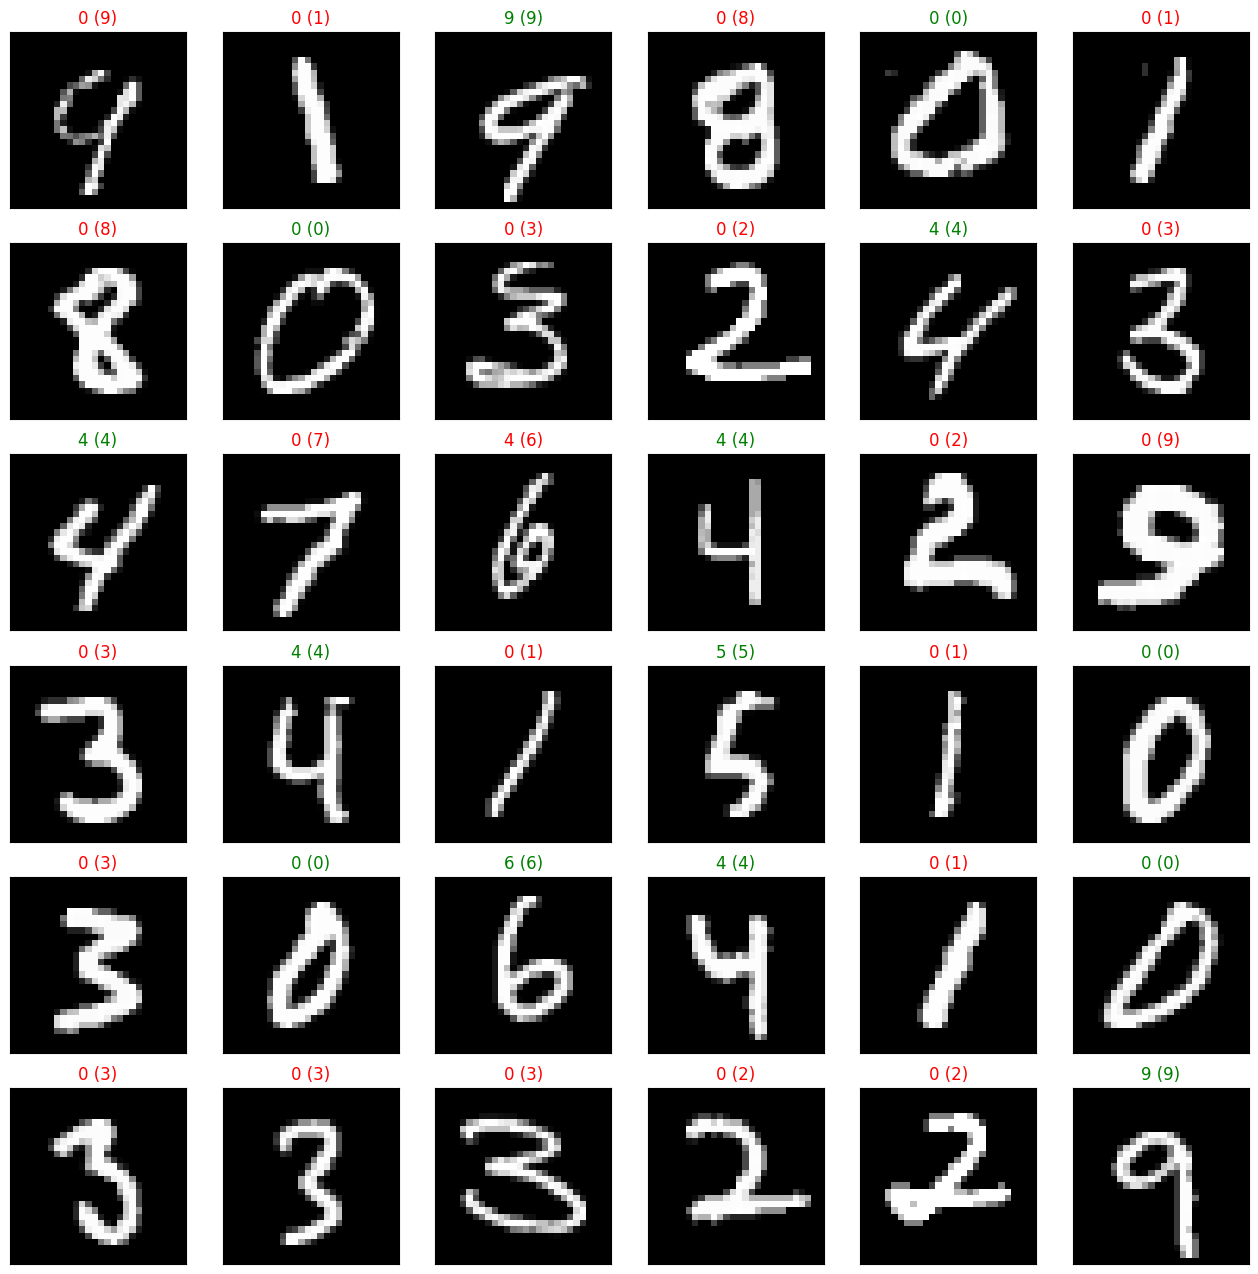

In [10]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
labels = labels.to(device)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# 시각화 위해 CPU 로 복귀
preds = preds.cpu()
labels = labels.cpu()
# prep images for display
images = images.cpu().numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(16, 16))
for idx in np.arange(36):
    ax = fig.add_subplot(6, 6, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))